In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad

import pickle

In [116]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'

adata=sc.read_h5ad(PATH)
adata=adata[adata.obs["tech"]=="xenium"]

In [117]:
KEEP = ['BK22_Lesional Baseline',
'BK30_Day 14',
"BK49_Past Lesional",
 "BK27_Week 12",
'Lesional_CE4-SKI-27-FO-4-S22-A2',
'BK22-SKI-27-FO-1-S34-D1',
        'Lesional_CE3-SKI-24-FO-1-S22-A1',
        'BK39_Lesional Baseline',
'BK51_wk8 Relapse',
'BK25_Week 12',
'BK21_Week 12',
"BK25-SKI-27-FO-5",
"BK23_Week 12",
'BK27_Lesional Baseline',
'BK24_Lesional Baseline'
        
       ]


In [118]:
adata_i=adata[(adata.obs["info_id6"].isin(KEEP))|
              (adata.obs["info_id2"].isin(KEEP))
             ]
adata_i.obs["sample_id"].value_counts()

sample_id
BK30_Day 14                        30438
BK49_Past Lesional                 27387
3D_BK22_Lesional_baseline-D1       23777
Lesional_CE3-SKI-24-FO-1-S22-A1    22124
BK22_Lesional Baseline             21567
Lesional_CE4-SKI-27-FO-4-S22-A2    20471
BK39_Lesional Baseline             16503
BK51_wk8 Relapse                   14433
BK25_Week 12                       13999
BK27_Week 12                       13422
BK24_Lesional Baseline             12954
BK23_Week 12                       11247
BK21_Week 12                        8978
BK27_Lesional Baseline              7907
Name: count, dtype: int64

In [120]:
[x for x in adata.obs["info_id6"].unique() if x.startswith("Lesional_CE3")]

['Lesional_CE3-SKI-24-FO-1-S22-A1', 'Lesional_CE3-SKI-24-FO-1-S22_replicate']

In [21]:
adata_i.obs['Xenium slide number'].value_counts()

Xenium slide number
nan          48954
X0043607     30438
psoriasis    20471
X0027175     13422
Name: count, dtype: int64

In [22]:
adata_i.obs[ 'Xenium region number2'].value_counts()

Xenium region number2
MISSING      79392
psoriasis    20471
1            13422
Name: count, dtype: int64

In [16]:
adata_i.obs['Sample ID'].value_counts()

Sample ID
BK30-SKI-28-FO-1       30438
BK49-SKI-21-FO-1       27387
BK22-SKI-27-FO-1       21567
psoriasis              20471
BK27-SKI-27-FO-5-S6    13422
Name: count, dtype: int64

In [18]:

adata_i.obs['xenium_id'].value_counts()

xenium_id
BK30-SKI-28-FO-1-S3-4      30438
BK49-SKI-21-FO-1-s2        27387
BK22-SKI-27-FO-1-S34-D1    23777
BK22-SKI-27-FO-1-S10-A1    21567
CE4-SKI-27-FO-4-S22-A2     20471
X0027175_Region 1          13422
Name: count, dtype: int64

In [15]:
adata_i.obs['info_id'].value_counts()

info_id
BK30_Day 14               30438
BK49_Past Lesional        27387
BK22_Lesional Baseline    21567
psoriasis                 20471
BK27_Week 12              13422
Name: count, dtype: int64

In [96]:
import pandas as pd

# Make a DataFrame view of just the relevant columns
df = adata_i.obs[['info_id6', 'xenium_id']].copy()

# Compute the most common xenium_id per info_id6
most_common_dict = (
    df.groupby('info_id6')['xenium_id']
      .agg(lambda x: x.value_counts().idxmax())
      .to_dict()
)

most_common_dict

/tmp/ipykernel_2396306/1589067370.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('info_id6')['xenium_id']


{'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1',
 'BK21_Week 12': 'X0027175_Region 6',
 'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',
 'BK23_Week 12': 'BK23-SKI-27-FO-5-S6-E2',
 'BK24_Lesional Baseline': 'BK24-SKI-28-FO-1-2-S3',
 'BK25_Week 12': 'BK25-SKI-27-FO-5-S3',
 'BK27_Lesional Baseline': 'X0027175_Region 2',
 'BK27_Week 12': 'X0027175_Region 1',
 'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4',
 'BK39_Lesional Baseline': 'BK39-SKI-27-FO-1-S3',
 'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2',
 'BK51_wk8 Relapse': 'BK51-SKI-27-FO-2-s2',
 'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}

In [24]:
import pandas as pd

# Make a DataFrame view of just the relevant columns
df = adata_i.obs[['Xenium slide number', 'xenium_id']].copy()

# Compute the most common xenium_id per info_id6
most_common_dict = (
    df.groupby('Xenium slide number')['xenium_id']
      .agg(lambda x: x.value_counts().idxmax())
      .to_dict()
)

most_common_dict

/tmp/ipykernel_2396306/1605056526.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Xenium slide number')['xenium_id']


{'X0027175': 'X0027175_Region 1',
 'X0043607': 'BK30-SKI-28-FO-1-S3-4',
 'nan': 'BK49-SKI-21-FO-1-s2',
 'psoriasis': 'CE4-SKI-27-FO-4-S22-A2'}

In [ ]:
{'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1', 
 'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',  # sgp205
 'BK27_Week 12': 'X0027175_Region 1',# AF_ECZ5K 
 'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4', #sgp 194
 'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2', # SGP 217
 'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}


In [ ]:
# smb://wsidata-s1/t298_imaging/0XeniumExports/20241107_SGP205_5K_BEACON_WARTS/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553

In [36]:

import os
[x for x in os.listdir('/nfs/team298/beacon_ls34/')  if "SGP205" in x]

['20240628__123954__AF_ECZ5K_human_skin_BEACON_1']

In [29]:
[x for x in os.listdir('/nfs/team298/beacon_ls34/20241107__113135__SGP205_SKI_run1') if 'BK22-SKI-27-FO-1-S10-A1' in x]

['output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553']

In [30]:
os.listdir('/nfs/team298/beacon_ls34/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553')

['experiment.xenium',
 'gene_panel.json',
 'analysis.zarr.zip',
 'cells.csv.gz',
 'cells.zarr.zip',
 'cell_boundaries.csv.gz',
 'metrics_summary.csv',
 'aux_outputs',
 'cell_feature_matrix.h5',
 'transcripts.zarr.zip',
 'transcripts.parquet',
 '.end-of-run',
 'cell_boundaries.parquet',
 'nucleus_boundaries.parquet',
 'analysis_summary.html',
 'morphology.ome.tif',
 'cells.parquet',
 'cell_feature_matrix',
 'analysis',
 'cell_feature_matrix.zarr.zip',
 'nucleus_boundaries.csv.gz',
 'morphology_focus']

In [31]:
BK22_PATH = '/nfs/team298/beacon_ls34/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553'


In [32]:
new_path = BK22_PATH

adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
adata

AnnData object with n_obs × n_vars = 23112 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

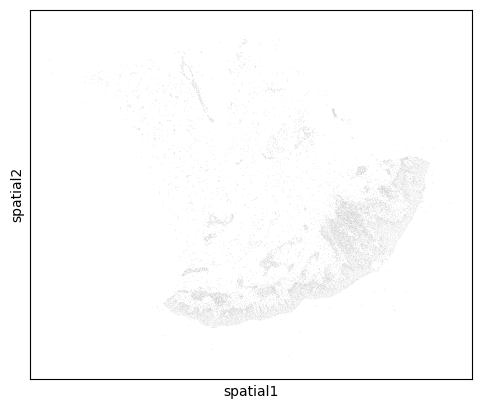

In [35]:
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [40]:
import os
[x for x in os.listdir('/nfs/team298/beacon_ls34/')  if "AF_ECZ5K" in x]

['20240628__123954__AF_ECZ5K_human_skin_BEACON_1']

In [47]:
# {'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1',
#  'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1', 
#  'BK27_Week 12': 'X0027175_Region 1',
#  'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4',
#  'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2',
#  'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}
[x for x in os.listdir('/nfs/team298/beacon_ls34/20240628__123954__AF_ECZ5K_human_skin_BEACON_1') if 'Region_1' in x]

['output-XETG00272__0027175__Region_1__20240628__124459',
 'output-XETG00272__0027131__Region_1__20240628__124459']

In [48]:
new_path = '/nfs/team298/beacon_ls34/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/output-XETG00272__0027175__Region_1__20240628__124459'

adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

AnnData object with n_obs × n_vars = 18066 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

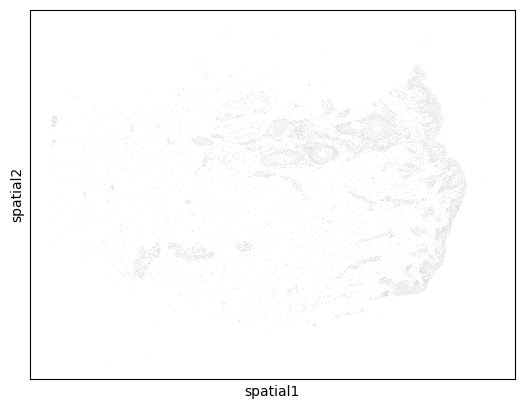

In [49]:
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [51]:
# {'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1', 
#  'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',  # sgp205
#  'BK27_Week 12': 'X0027175_Region 1',# AF_ECZ5K 
#  'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4', #sgp 194
#  'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2', # SGP 217
#  'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}
import os
[x for x in os.listdir('/nfs/team298/beacon_ls34/')  if "SGP194" in x]

['20241010__132615__SGP194_SKI_RUN1']

In [52]:
[x for x in os.listdir('/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/') if 'BK30-SKI-28-FO-1-S3-4' in x]

['output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127']

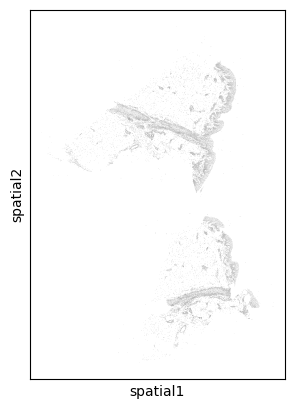

In [53]:
new_path = '/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127'

adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [54]:
# {'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1', 
#  'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',  # sgp205
#  'BK27_Week 12': 'X0027175_Region 1',# AF_ECZ5K 
#  'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4', #sgp 194
#  'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2', # SGP 217
#  'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}
import os
[x for x in os.listdir('/nfs/team298/beacon_ls34/')  if "SGP217" in x]

['20250210__162905__SGP217_LP1']

In [56]:
PATH = '/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/'
[x for x in os.listdir(PATH) if 'K49-SKI-21-FO-1-s2' in x]

['output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417']

/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417


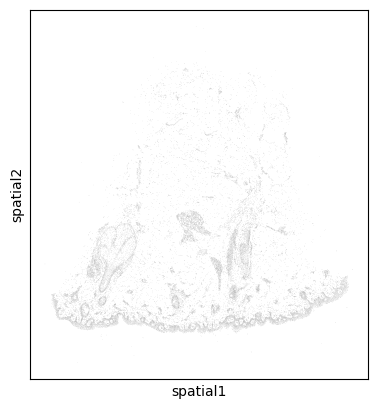

In [59]:
new_path = PATH + 'output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [63]:
# {'3D_BK22_Lesional_baseline-D1': 'BK22-SKI-27-FO-1-S34-D1', 
#  'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',  # sgp205
#  'BK27_Week 12': 'X0027175_Region 1',# AF_ECZ5K 
#  'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4', #sgp 194
#  'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2', # SGP 217
#  'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}
import os
[x for x in os.listdir('/nfs/team298/beacon_ls34/')  if "3D" in x]

['20250710_SGP263_5K_3Dniche']

In [69]:
PATH = '/nfs/team298/beacon_ls34/20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/'
[x for x in os.listdir(PATH) if 'BK22-SKI-27-FO-1-S34-D1' in x]

['output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204']

/nfs/team298/beacon_ls34/20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204


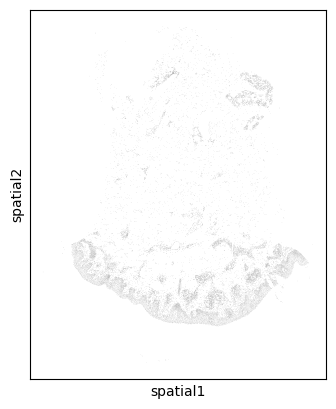

In [70]:
new_path = PATH + 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [ ]:
 {'3D_BK22_Lesional_baseline-D1': '/nfs/team298/beacon_ls34/20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204', 
#  'BK22_Lesional Baseline': 'BK22-SKI-27-FO-1-S10-A1',  # sgp205
#  'BK27_Week 12': 'X0027175_Region 1',# AF_ECZ5K 
#  'BK30_Day 14': 'BK30-SKI-28-FO-1-S3-4', #sgp 194
#  'BK49_Past Lesional': 'BK49-SKI-21-FO-1-s2', # SGP 217
#  'Lesional_CE4-SKI-27-FO-4-S22-A2': 'CE4-SKI-27-FO-4-S22-A2'}
/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417


In [82]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH)] #if 'CE4-SKI-27-FO-4-S22-A2' in x]

['20240409_run1_skin_nosegmentation',
 '20240711__110557__SGP174_SKI_run1_skin segmented',
 '.ipynb_checkpoints',
 '20250710_SGP263_5K_3Dniche',
 'adata_xeniumimmunooncology_processed.h5ad',
 '20240815__115640__SGP177_SKI_run1',
 'paths_all2.csv',
 '20250326_SGP237_5K_BSTOP Pso FF',
 'loaded_adatas',
 '20241107__113135__SGP205_SKI_run1',
 '20240624__145030_immunoncologypanel_segmented',
 'H&Es 07112024',
 '20240628__123954__AF_ECZ5K_human_skin_BEACON_1',
 '20241010__132615__SGP194_SKI_RUN1',
 'visium_pilot',
 'paths_all.csv',
 '20250227_SGP218_5K_BEACONomics_FFPE',
 'cellranger_data',
 'downloadfiles.sh',
 '20250210__162905__SGP217_LP1',
 'adata_xeniumimmunooncology_processed.h5ad.newnotebooks']

In [85]:
PATH = '/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/'
[x for x in os.listdir(PATH) if 'CE4-SKI-27-FO-4-S22-A2' in x]

['output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338',
 'output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447']

/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338


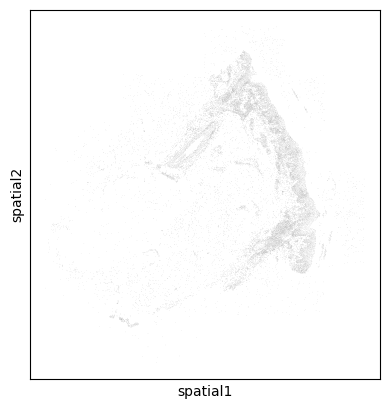

In [90]:
new_path = PATH + 'output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447


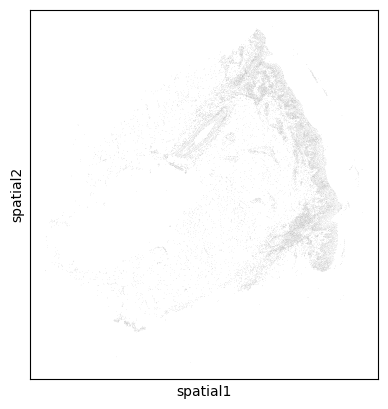

In [88]:
new_path = PATH + 'output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [ ]:
PATH = '/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/'
[x for x in os.listdir(PATH) if 'CE4-SKI-27-FO-4-S22-A2' in x]

In [97]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH) if 'SGP194' in x]

['20241010__132615__SGP194_SKI_RUN1']

In [98]:
PATH = '/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/'
[x for x in os.listdir(PATH) if 'BK39-SKI-27-FO-1-S3' in x]

['output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127']

/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127


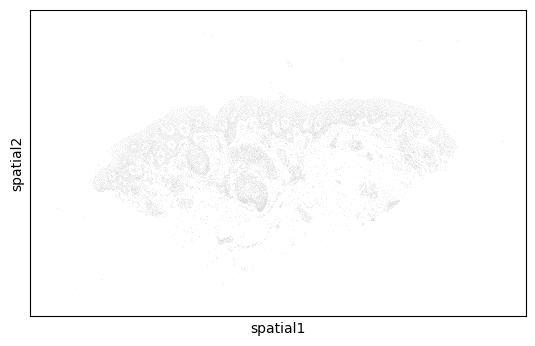

In [99]:
new_path = PATH + 'output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [100]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH) if 'AF_ECZ5K' in x]

['20240628__123954__AF_ECZ5K_human_skin_BEACON_1']

In [104]:

PATH = '/nfs/team298/beacon_ls34/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/'
[x for x in os.listdir(PATH) if 'Region_6' in x]

['output-XETG00272__0027131__Region_6__20240628__124459',
 'output-XETG00272__0027175__Region_6__20240628__124459']

/nfs/team298/beacon_ls34/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/output-XETG00272__0027175__Region_6__20240628__124459


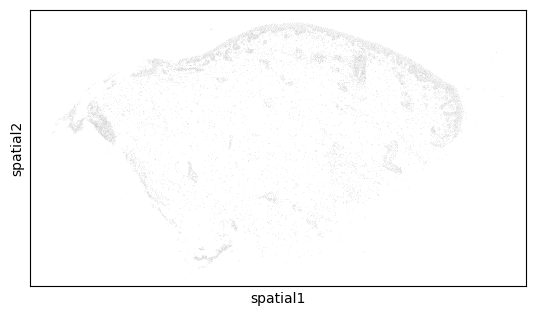

In [105]:
new_path = PATH + 'output-XETG00272__0027175__Region_6__20240628__124459'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [106]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH) if 'SGP205' in x]

['20241107__113135__SGP205_SKI_run1']

In [107]:

PATH = '/nfs/team298/beacon_ls34/20241107__113135__SGP205_SKI_run1/'
[x for x in os.listdir(PATH) if 'BK23-SKI-27-FO-5-S6-E2' in x]

['output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553']

/nfs/team298/beacon_ls34/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553


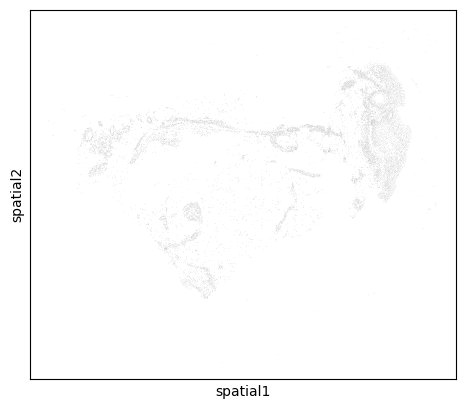

In [108]:
new_path = PATH + 'output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [109]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH) if 'SGP194' in x]

['20241010__132615__SGP194_SKI_RUN1']

In [111]:

PATH = '/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/'
[x for x in os.listdir(PATH) if 'BK24-SKI-28-FO-1-2-S3' in x]

['output-XETG00155__0043604__BK24-SKI-28-FO-1-2-S3__20241010__133127']

/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043604__BK24-SKI-28-FO-1-2-S3__20241010__133127


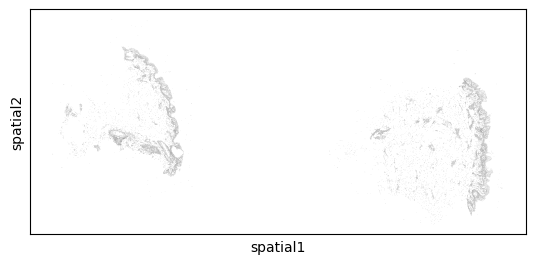

In [112]:
new_path = PATH + 'output-XETG00155__0043604__BK24-SKI-28-FO-1-2-S3__20241010__133127'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [113]:
# BK24-SKI-28-FO-1-2-S3

In [36]:
PATH = '/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/'
[x for x in os.listdir(PATH) if 'CE3-SKI-24-FO-1-S22-A1' in x]

FileNotFoundError: [Errno 2] No such file or directory: '/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/'

In [37]:
new_path = PATH + 'output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447/cell_feature_matrix.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [39]:
PATHS  = {'3D_BK22_Lesional_baseline-D1': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k//20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204', 
 'BK22_Lesional Baseline':  '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
 'BK23_Week 12': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553',
 'BK27_Week 12': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/output-XETG00272__0027175__Region_1__20240628__124459',
 'BK30_Day 14': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127',
 'BK39_Lesional Baseline': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127',
 'BK49_Past Lesional': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417',
 'BK51_wk8 Relapse': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417',
 'Lesional_CE4-SKI-27-FO-4-S22-A2': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338',
  
 
 
         'Lesional_CE3-SKI-24-FO-1-S22-A1': '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447'
}



 #'BK24_Lesional Baseline': 'BK24-SKI-28-FO-1-2-S3',
 #'BK25_Week 12': 'BK25-SKI-27-FO-5-S3',
 #'BK27_Lesional Baseline': 'X0027175_Region 2',

In [43]:
os.listdir(
    
'/nfs/team298/beacon_ls34/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127/')

['experiment.xenium',
 'gene_panel.json',
 'analysis.zarr.zip',
 'cells.csv.gz',
 'cells.zarr.zip',
 'cell_boundaries.csv.gz',
 'metrics_summary.csv',
 'aux_outputs',
 'cell_feature_matrix.h5',
 'transcripts.zarr.zip',
 'transcripts.parquet',
 '.end-of-run',
 'cell_boundaries.parquet',
 'nucleus_boundaries.parquet',
 'analysis_summary.html',
 'morphology.ome.tif',
 'cells.parquet',
 'cell_feature_matrix',
 'analysis',
 'cell_feature_matrix.zarr.zip',
 'nucleus_boundaries.csv.gz',
 'morphology_focus']

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k//20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204/


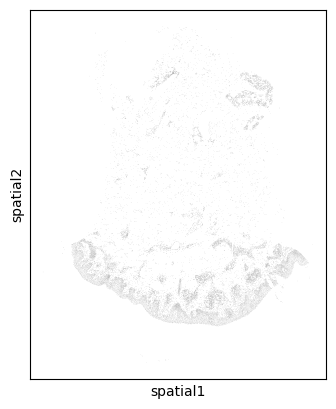

3D_BK22_Lesional_baseline-D1 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k//20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553/
##error


/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553/
##error


/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/output-XETG00272__0027175__Region_1__20240628__124459/


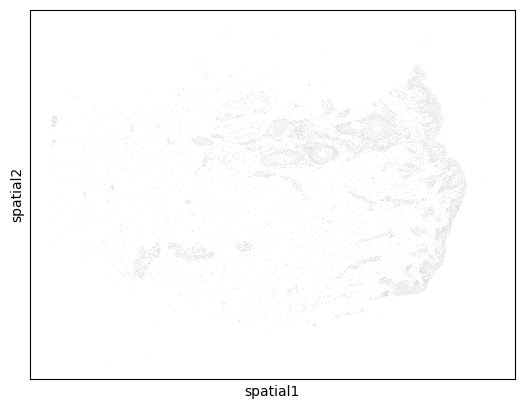

BK27_Week 12 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20240628__123954__AF_ECZ5K_human_skin_BEACON_1/output-XETG00272__0027175__Region_1__20240628__124459
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127/
##error


/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127/
##error


/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417/


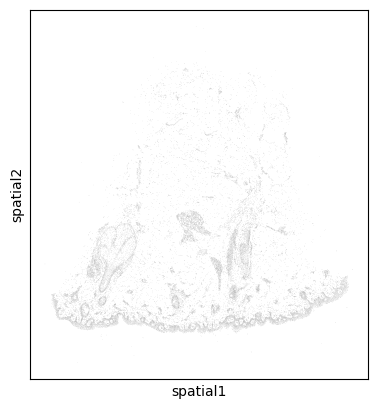

BK49_Past Lesional :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417/


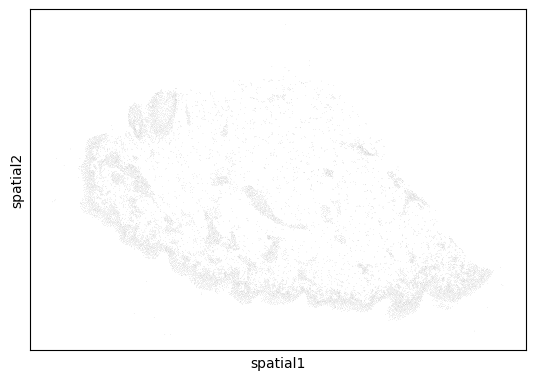

BK51_wk8 Relapse :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250210__162905__SGP217_LP1/output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338/


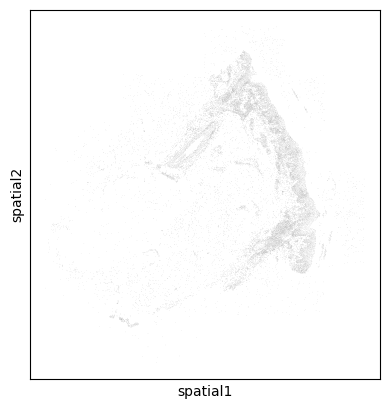

Lesional_CE4-SKI-27-FO-4-S22-A2 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00272__0056918__CE4-SKI-27-FO-4-S22-A2__20250404__123338
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447/


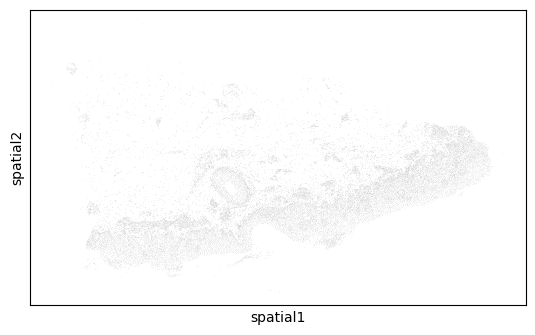

Lesional_CE3-SKI-24-FO-1-S22-A1 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447
['/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553', '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553', '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127', '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127']


In [45]:
import scanpy as sc
import pandas as pd
ERRORS = [ ]
for k,v in PATHS.items():
    #print(v)
    new_path = v+'/'
    print(new_path)
    try :
        adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
        df = pd.read_csv(new_path+"/cells.csv.gz")
        df.set_index(adata.obs_names, inplace=True)
        adata.obs = df.copy()
        adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

        sc.pl.spatial(
                adata,
                #library_id="spatial",
                #shape=None,
                #color="cell_id",
                spot_size=1,
                vmax=1,
                #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
                edgecolor="black",
                linewidth=0.1,
                legend_fontsize=6,


            )
        print(k , ": ", v)
    except:
        
        print("##error\n\n")
        ERRORS.append(v)
print(ERRORS)

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553/


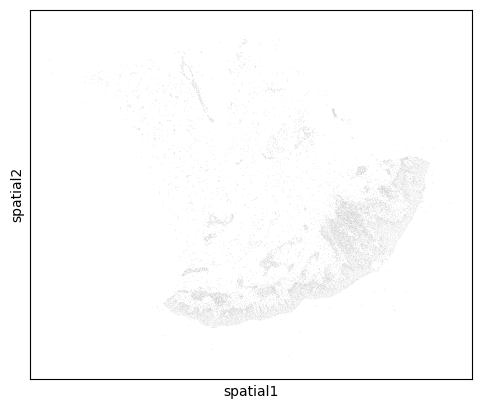

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553/


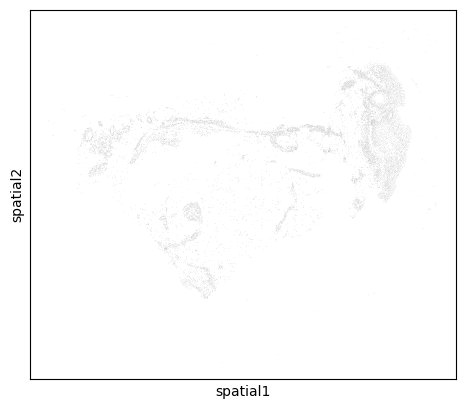

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127/


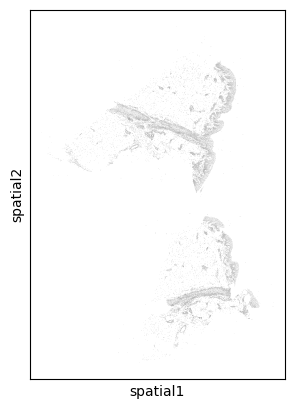

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127/


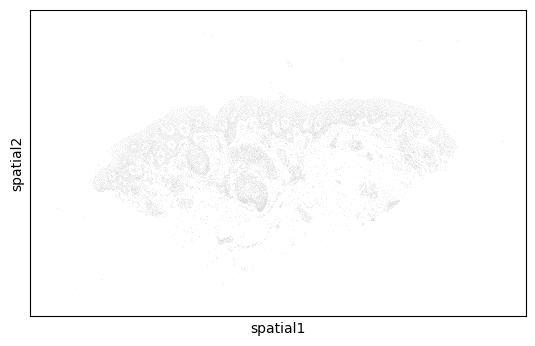

In [51]:
import scanpy as sc
import pandas as pd
#ERRORS = [ ]
for v in ERRORS:
    #print(v)
    new_path = v+'/'
    print(new_path)
    try :
        adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
        df = pd.read_csv(new_path+"/cells.csv.gz")
        df.set_index(adata.obs_names, inplace=True)
        adata.obs = df.copy()
        adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

        sc.pl.spatial(
                adata,
                #library_id="spatial",
                #shape=None,
                #color="cell_id",
                spot_size=1,
                vmax=1,
                #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
                edgecolor="black",
                linewidth=0.1,
                legend_fontsize=6,


            )
    except:
        
        print("##error\n\n")
       # ERRORS.append(v)

/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553/


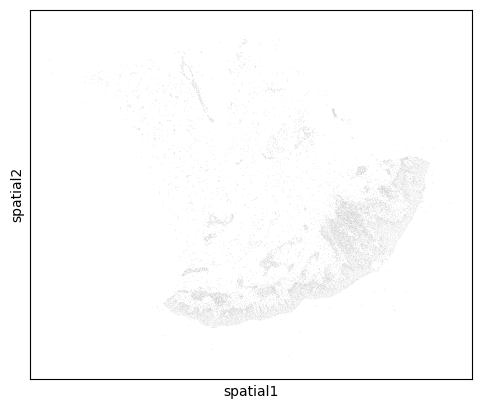

BK22_Lesional Baseline :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553/


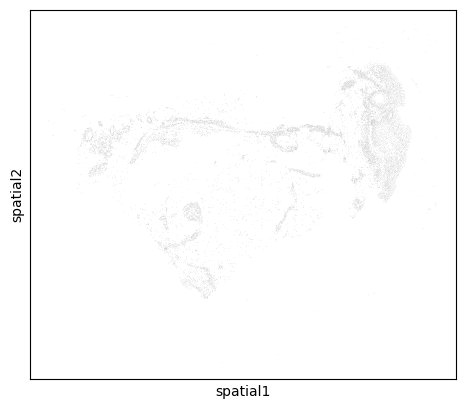

BK23_Week 12 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241107__113135__SGP205_SKI_run1/output-XETG00272__0041416__BK23-SKI-27-FO-5-S6-E2__20241107__113553
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127/


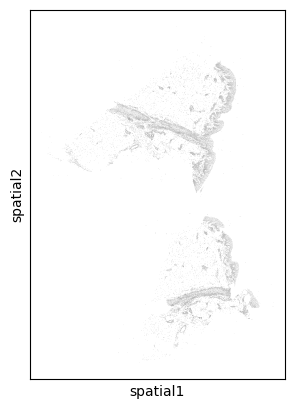

BK30_Day 14 :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127
/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127/


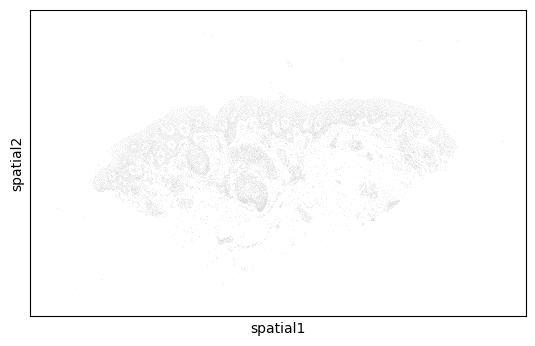

BK39_Lesional Baseline :  /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20241010__132615__SGP194_SKI_RUN1/output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127


In [53]:
import scanpy as sc
import pandas as pd
for k,v in PATHS.items():
    if v in ERRORS:
        new_path = v+'/'
        print(new_path)
        try :
            adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
            df = pd.read_csv(new_path+"/cells.csv.gz")
            df.set_index(adata.obs_names, inplace=True)
            adata.obs = df.copy()
            adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

            sc.pl.spatial(
                    adata,
                    #library_id="spatial",
                    #shape=None,
                    #color="cell_id",
                    spot_size=1,
                    vmax=1,
                    #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
                    edgecolor="black",
                    linewidth=0.1,
                    legend_fontsize=6,


                )
            print(k , ": ", v)
        except:

            print("##error\n\n")



In [ ]:
mv /nfs/team298/beacon_ls34/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447/* /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/20250326_SGP237_5K_BSTOP Pso FF/20250321__125835__SGP237_run1/output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447/*

In [15]:
import os
os.listdir('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k/')

['20250210__162905__SGP217_LP1',
 '20240409_run1_skin_nosegmentation',
 '20240624__145030_immunoncologypanel_segmented',
 '20250326_SGP237_5K_BSTOP Pso FF',
 '20240628__123954__AF_ECZ5K_human_skin_BEACON_1',
 '20250227_SGP218_5K_BEACONomics_FFPE',
 '20250710_SGP263_5K_3Dniche']

In [48]:
0

0

In [49]:
1


1

In [123]:
PATH = '/nfs/team298/beacon_ls34//'
[x for x in os.listdir(PATH) if 'SGP217' in x]

['20250210__162905__SGP217_LP1']

In [124]:
PATH = '/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/'
[x for x in os.listdir(PATH)]# if 'CE3-SKI-24-FO-1-S22-A1' in x]

['Post-Xenium H&E',
 'output-XETG00335__0044076__BK49-SKI-24-FO-3-s2__20250210__163417',
 'output-XETG00335__0044073__BK46-SKI-24-FO-3-s2__20250210__163417',
 'output-XETG00335__0044076__BK43-SKI-22-FO-1-s2_BK51-SKI-24-FO-2-s2__20250210__163417',
 'output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417',
 'output-XETG00335__0044073__BK46-SKI-24-FO-1-s2__20250210__163417',
 'output-XETG00335__0044073__BK43-SKI-21-FO-1-s2__20250210__163417',
 'output-XETG00335__0044076__BK51-SKI-28-FO-1-s2_BK43-SKI-24-FO-1-s2__20250210__163417',
 'output-XETG00335__0044076__BK46-SKI-27-FO-2-s3_BK46-SKI-27-FO-2-s2__20250210__163417',
 'output-XETG00335__0044073__BK49-SKI-24-FO-2-s2__20250210__163417',
 'output-XETG00335__0044073__BK49-SKI-22-FO-1-s2__20250210__163417',
 'output-XETG00335__0044073__BK49-SKI-21-FO-1-s2__20250210__163417',
 'output-XETG00335__0044073__BK49-SKI-24-FO-1-s2_BK50-SKI-27-FO-1-s2__20250210__163417',
 'output-XETG00335__0044076__BK51-SKI-24-FO-1-s2__20250210__163417',
 'o

In [125]:
PATH = '/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/'
[x for x in os.listdir(PATH) if 'BK51-SKI-27-FO-2' in x]

['output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417']

/nfs/team298/beacon_ls34/20250210__162905__SGP217_LP1/output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417


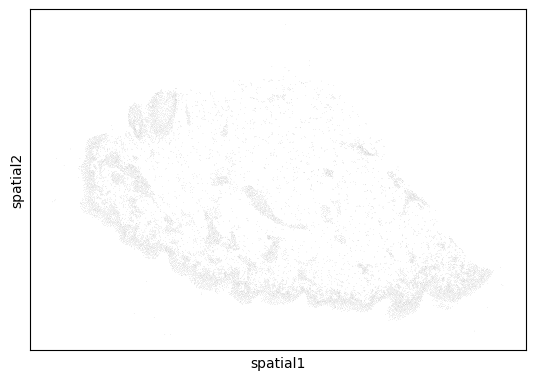

In [126]:
new_path = PATH + 'output-XETG00335__0044076__BK51-SKI-27-FO-2-s2__20250210__163417'
print(new_path)
adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
df = pd.read_csv(new_path+"/cells.csv.gz")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

#adatas_dict[sample_id] = adata
#print(adata)
#print()

#adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
#del(adatas_dict)
sc.pl.spatial(
        adata,
        #library_id="spatial",
        #shape=None,
        #color="cell_id",
        spot_size=1,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,


    )
 

In [ ]:
0

In [21]:
NEW = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_data/xenium_5k//20250710_SGP263_5K_3Dniche/20250710__123633__SGP263_Run1/output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204/'


In [46]:
# new_path = NEW
# print(new_path)
# adata = sc.read_10x_h5(filename=new_path+"/cell_feature_matrix.h5")
# df = pd.read_csv(new_path+"/cells.csv.gz")
# df.set_index(adata.obs_names, inplace=True)
# adata.obs = df.copy()
# adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

# #adatas_dict[sample_id] = adata
# #print(adata)
# #print()

# #adata = ad.concat(adatas_dict.values(), join='outer', label='sample_id', keys=list(adatas_dict.keys()))
# #del(adatas_dict)
# sc.pl.spatial(
#         adata,
#         #library_id="spatial",
#         #shape=None,
#         #color="cell_id",
#         spot_size=1,
#         vmax=1,
#         #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
#         edgecolor="black",
#         linewidth=0.1,
#         legend_fontsize=6,


#     )
 